In [23]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import shap
import lightgbm as lgb

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
shap.initjs()

In [24]:
# Load all CSV files in the specified folder into a single DataFrame
import glob, os

CSV_FOLDER = './MachineLearningCVE'          
csv_files = glob.glob(os.path.join(CSV_FOLDER, '*.csv'))

if csv_files:
    dfs = []
    for f in csv_files:
        print(f'Loading: {f}')
        tmp = pd.read_csv(f, low_memory=False)
        dfs.append(tmp)
    df = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal rows loaded: {len(df):,}')
else:
    raise FileNotFoundError('No CSV files found. Update CSV_FOLDER path.')

df.head()

Loading: ./MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv
Loading: ./MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv

Total rows loaded: 2,830,743


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [25]:
# Display basic info about the DataFrame
print('DataFrame Info:')
print(df.info())
print('Shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max    

In [26]:
# Standardise column names (strip spaces, common CICIDS quirk)
df.columns = df.columns.str.strip()

# Identify label column (CICIDS2017 uses ' Label' or 'Label')
LABEL_COL = 'Label'
if LABEL_COL not in df.columns:
    LABEL_COL = [c for c in df.columns if 'label' in c.lower()][0]
print(f'Label column: "{LABEL_COL}"')

print('\nClass distribution:')
print(df[LABEL_COL].value_counts())

Label column: "Label"

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


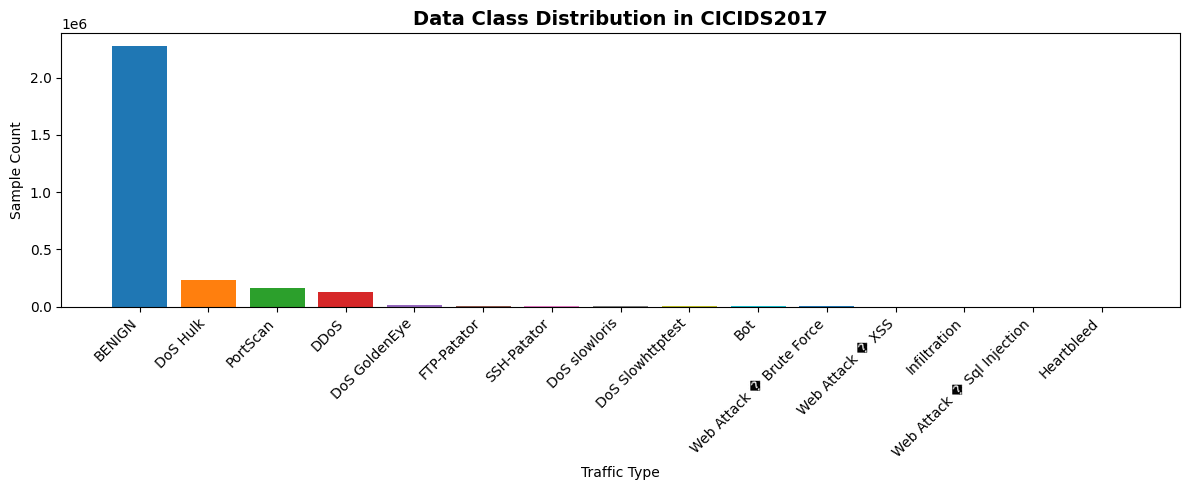

In [27]:
# Visualise class distribution
fig, ax = plt.subplots(figsize=(12, 5))
counts = df[LABEL_COL].value_counts()
ax.bar(counts.index, counts.values, color=plt.cm.tab10.colors[:len(counts)])
ax.set_title('Data Class Distribution in CICIDS2017', fontsize=14, fontweight='bold')
ax.set_xlabel('Traffic Type')
ax.set_ylabel('Sample Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
# Drop non-numeric / identifier columns
drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
             'Src IP', 'Dst IP', 'src_ip', 'dst_ip']
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

# Replace inf / -inf with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns with > 50% missing
thresh = len(df) * 0.5
df.dropna(axis=1, thresh=thresh, inplace=True)

# DROP rows with ANY NaN (simpler baseline approach)
print(f'Shape before dropping NaNs: {df.shape}')
df.dropna(inplace=True)
print(f'Shape after dropping NaNs : {df.shape}')

# KEEP DUPLICATES (don't remove them - baseline approach)
print(f'Missing values: {df.isnull().sum().sum()}')

Shape before dropping NaNs: (2830743, 79)
Shape after dropping NaNs : (2827876, 79)
Missing values: 0


In [29]:
# Encode labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL].astype(str))

class_names = le.classes_
n_classes   = len(class_names)
print(f'\nNumber of classes: {n_classes}')
for i, name in enumerate(class_names):
    print(f'  {i}: {name}')


Number of classes: 15
  0: BENIGN
  1: Bot
  2: DDoS
  3: DoS GoldenEye
  4: DoS Hulk
  5: DoS Slowhttptest
  6: DoS slowloris
  7: FTP-Patator
  8: Heartbleed
  9: Infiltration
  10: PortScan
  11: SSH-Patator
  12: Web Attack � Brute Force
  13: Web Attack � Sql Injection
  14: Web Attack � XSS


In [30]:
# Features / target split
X = df.drop(columns=[LABEL_COL, 'label_enc'])
X = X.select_dtypes(include=[np.number])   # keep only numeric
y = df['label_enc']

print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')

Features: 78  |  Samples: 2827876


In [31]:
# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (2262300, 78)  |  Test: (565576, 78)


In [32]:
params = {
    'objective'        : 'multiclass',
    'metric'           : 'multi_logloss',
    'num_class'        : n_classes,
    'n_estimators'     : 25,
    'learning_rate'    : 0.02,
    'max_depth'        : 4,
    'num_leaves'       : 12,
    'min_child_samples': 70,
    'subsample'        : 0.5,
    'colsample_bytree' : 0.5,
    'feature_fraction_seed' : 42,
    'bagging_fraction' : 0.5,
    'reg_alpha'        : 5.0,
    'reg_lambda'       : 5.0,
    'class_weight'     : 'balanced',
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1,
}

model = lgb.LGBMClassifier(**params)

model.fit(
    X_train, y_train,
    eval_set   =[(X_test, y_test)],
    callbacks  =[lgb.log_evaluation(10)],
)

print(f'Model training complete')

[10]	valid_0's multi_logloss: 1.66724
[20]	valid_0's multi_logloss: 1.22154
Model training complete


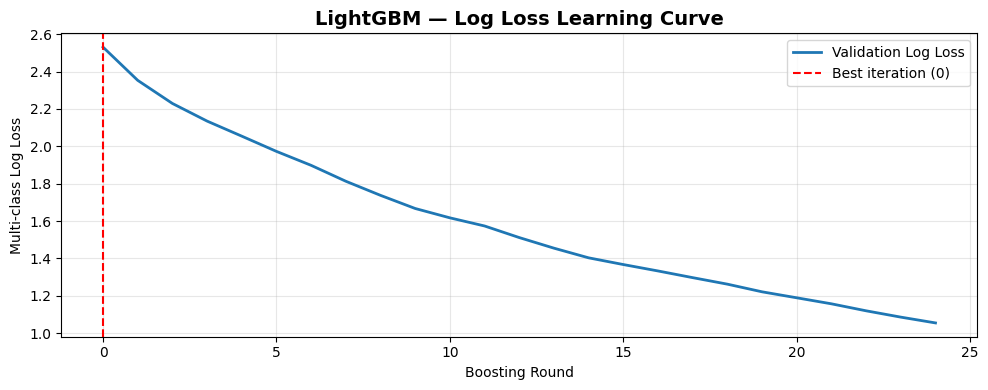

In [33]:
# Extract log loss history for training and validation
results = model.evals_result_
train_loss = results.get('training', {}).get('multi_logloss', [])
val_loss   = results.get('valid_0', {}).get('multi_logloss', [])

plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot(train_loss, label='Train Log Loss', linewidth=2)
if val_loss:
    plt.plot(val_loss, label='Validation Log Loss', linewidth=2)
plt.axvline(x=model.best_iteration_, color='red', linestyle='--',
            label=f'Best iteration ({model.best_iteration_})')
plt.title('LightGBM — Log Loss Learning Curve', fontsize=14, fontweight='bold')
plt.xlabel('Boosting Round')
plt.ylabel('Multi-class Log Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Predict on test set
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)   

# Accuracy
acc = accuracy_score(y_test, y_pred)

# Precision / Recall / F1 (weighted) 
prec    = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec     = recall_score   (y_test, y_pred, average='weighted', zero_division=0)
f1      = f1_score       (y_test, y_pred, average='weighted', zero_division=0)

# Log Loss
ll = log_loss(y_test, y_pred_prob)

# AUC-ROC (One-vs-Rest, weighted)
auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')


print('          EVALUATION METRICS (Test Set)')
print(f'  Accuracy          : {acc:.4f}')
print(f'  Precision (w-avg) : {prec:.4f}')
print(f'  Recall    (w-avg) : {rec:.4f}')
print(f'  F1-Score  (w-avg) : {f1:.4f}')
print(f'  Log Loss          : {ll:.4f}')
print(f'  AUC-ROC   (w-avg) : {auc:.4f}')

          EVALUATION METRICS (Test Set)
  Accuracy          : 0.9241
  Precision (w-avg) : 0.9874
  Recall    (w-avg) : 0.9241
  F1-Score  (w-avg) : 0.9525
  Log Loss          : 1.0551
  AUC-ROC   (w-avg) : 0.9973


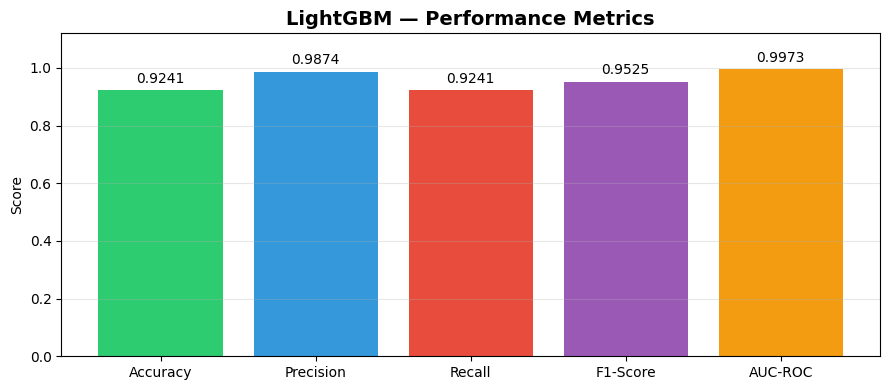

Log Loss: 1.0551  (lower is better, not plotted above)


In [35]:
# Metrics bar chart 
metrics = {
    'Accuracy' : acc,
    'Precision': prec,
    'Recall'   : rec,
    'F1-Score' : f1,
    'AUC-ROC'  : auc,
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=['#2ecc71','#3498db','#e74c3c','#9b59b6','#f39c12'])
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_title('LightGBM — Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Also print log loss separately (it is not 0-1 scale)
print(f'Log Loss: {ll:.4f}  (lower is better, not plotted above)')

In [36]:
# Classification report (per-class precision, recall, f1-score)
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    zero_division=0
))

                            precision    recall  f1-score   support

                    BENIGN       1.00      0.91      0.95    454265
                       Bot       0.02      1.00      0.04       391
                      DDoS       0.99      1.00      0.99     25605
             DoS GoldenEye       0.50      0.99      0.66      2059
                  DoS Hulk       0.95      0.99      0.97     46025
          DoS Slowhttptest       0.68      0.99      0.81      1100
             DoS slowloris       0.39      0.96      0.55      1159
               FTP-Patator       0.67      1.00      0.81      1587
                Heartbleed       0.02      1.00      0.04         2
              Infiltration       0.00      1.00      0.00         7
                  PortScan       0.99      1.00      0.99     31761
               SSH-Patator       0.40      1.00      0.57      1180
  Web Attack � Brute Force       0.10      0.47      0.16       301
Web Attack � Sql Injection       0.00      1.00

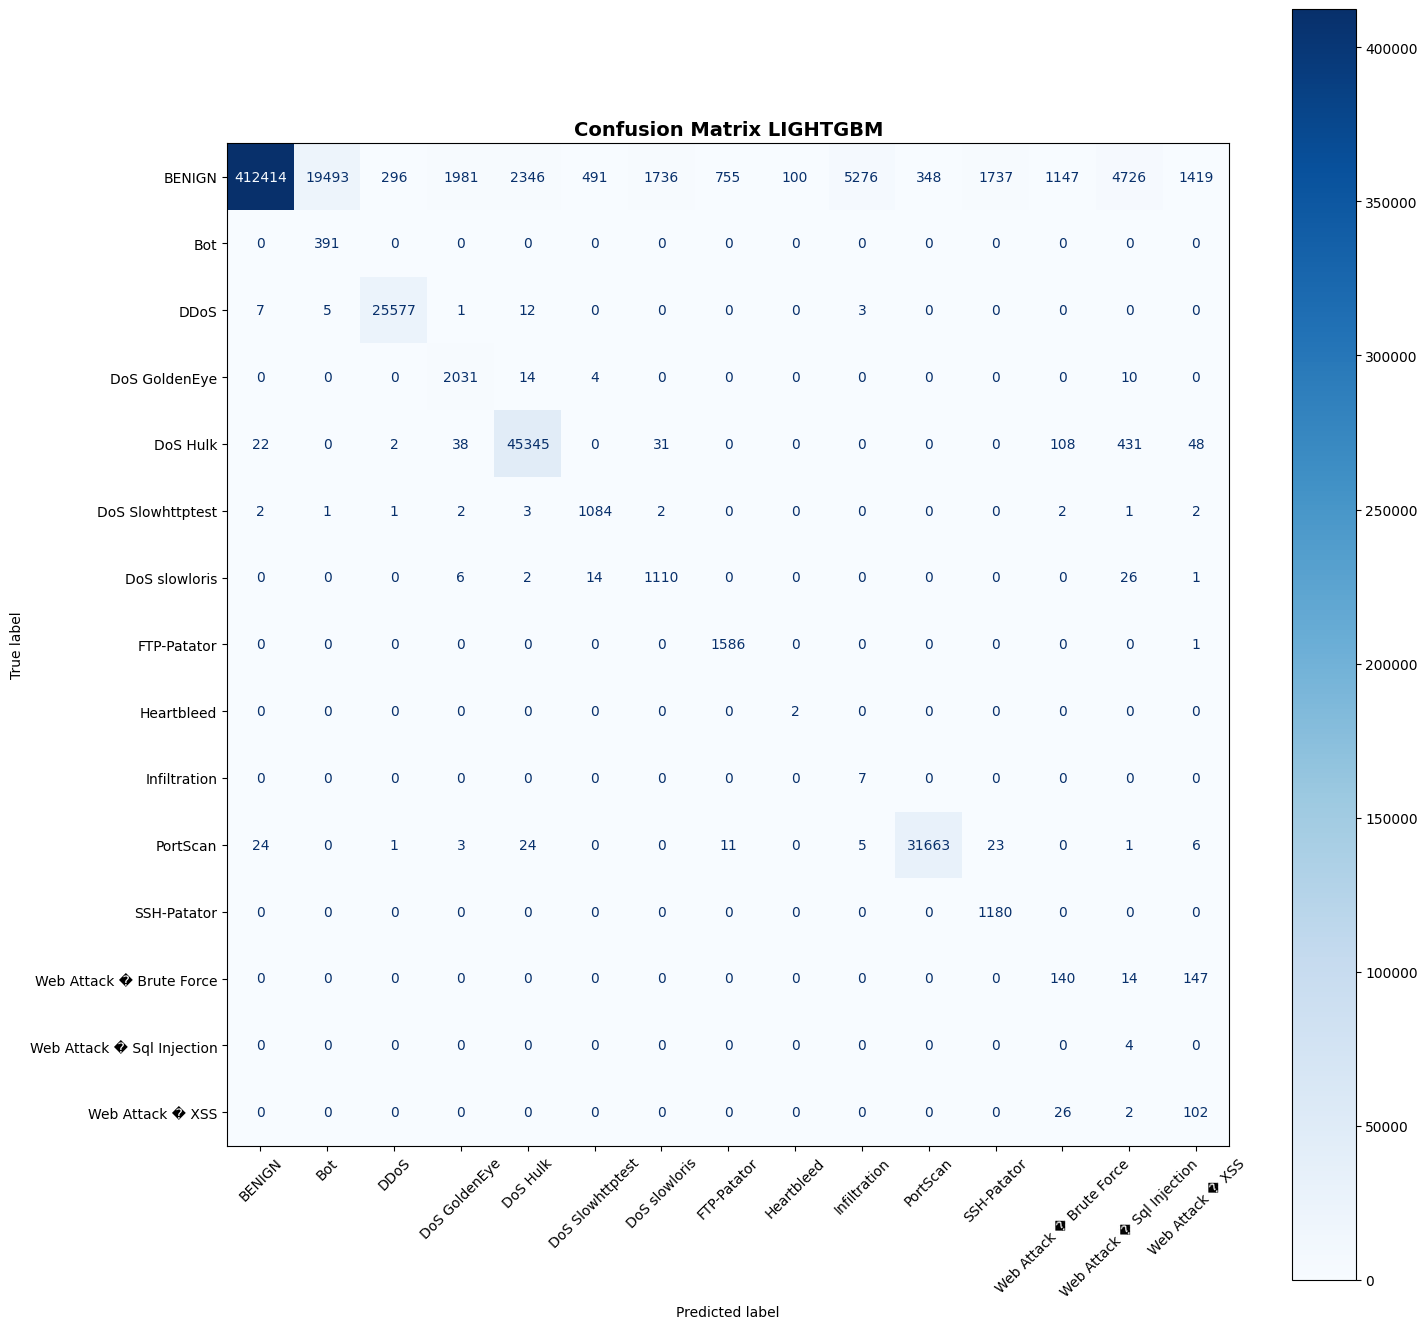

In [45]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(max(8, n_classes), max(6, n_classes - 1)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45)
ax.set_title('Confusion Matrix LIGHTGBM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

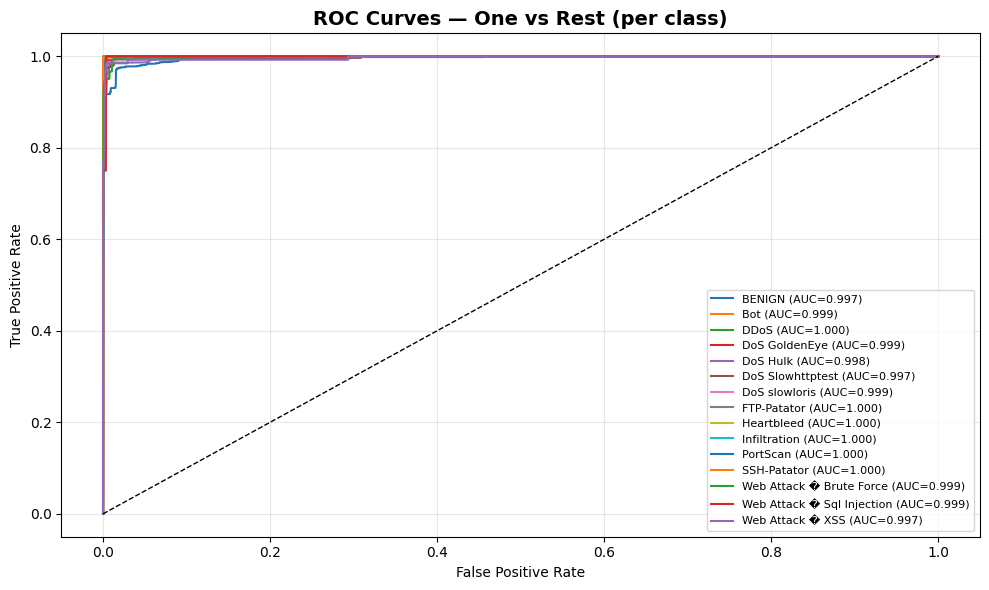

In [38]:
# ROC Curves (One-vs-Rest) with AUC per class
from sklearn.metrics import roc_curve, auc as sk_auc

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_i   = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=1.5, color=colors[i % 10],
            label=f'{class_names[i]} (AUC={roc_auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('ROC Curves — One vs Rest (per class)', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Correlation Analysis with Labels — Check for Perfect Separation
print('=' * 60)
print('FEATURE-LABEL CORRELATION (Perfect Separation Detector)')
print('=' * 60)

# Calculate correlation between features and encoded labels
correlations = []
for col in X.columns:
    corr = X[col].corr(y)
    correlations.append({
        'Feature': col,
        'Correlation_with_Label': abs(corr)  # Use absolute correlation
    })

corr_df = pd.DataFrame(correlations).sort_values('Correlation_with_Label', ascending=False)
print('\nTop 10 features with HIGHEST correlation to label:')
print(corr_df.head(10).to_string(index=False))

# If any correlation is very high (>0.9), it suggests the feature encodes the label
high_corr = corr_df[corr_df['Correlation_with_Label'] > 0.9]
if len(high_corr) > 0:
    print(f'\n🚨 WARNING: {len(high_corr)} features have correlation > 0.9 with label!')
    print('   These features may encode the attack type directly.\n')
    print(high_corr.to_string(index=False))
else:
    print('\n✅ No extreme correlations detected (all < 0.9)')

# Class separability via LightGBM predictions
print('\n' + '=' * 60)
print('CLASS SEPARABILITY TEST')
print('=' * 60)
print('\nPrediction confidence per class (entropy measure):')
pred_entropy = []
for i, class_name in enumerate(class_names):
    class_probs = y_pred_prob[:, i]
    # Shannon entropy: lower = more certain predictions
    entropy = -np.mean([p * np.log(p + 1e-10) + (1-p) * np.log(1-p + 1e-10) 
                       for p in class_probs])
    pred_entropy.append({'Class': class_name, 'Entropy': entropy, 'Avg_Prob': class_probs.mean()})

entropy_df = pd.DataFrame(pred_entropy).sort_values('Entropy')
print(entropy_df.to_string(index=False))
print('\n⚠️  Lower entropy = model is very confident (potential overfitting/leakage)')
print('   Healthy entropy should be > 0.3 for uncertain classes')


FEATURE-LABEL CORRELATION (Perfect Separation Detector)

Top 10 features with HIGHEST correlation to label:
              Feature  Correlation_with_Label
       PSH Flag Count                0.305556
    Min Packet Length                0.254442
Bwd Packet Length Min                0.227037
          Fwd IAT Std                0.206061
            Idle Mean                0.187888
             Idle Min                0.187302
             Idle Max                0.186465
          Fwd IAT Max                0.182586
Bwd Packet Length Std                0.182386
         Flow IAT Max                0.181374

✅ No extreme correlations detected (all < 0.9)

CLASS SEPARABILITY TEST

Prediction confidence per class (entropy measure):
                     Class  Entropy  Avg_Prob
                Heartbleed 0.166494  0.039868
               FTP-Patator 0.168870  0.041538
               SSH-Patator 0.171622  0.042195
          Web Attack � XSS 0.173836  0.042559
             DoS GoldenEye 0.17

TOP 20 MOST IMPORTANT FEATURES (Data Leakage Detection)
                    Feature  Importance
           Destination Port         233
    Init_Win_bytes_backward         175
     Init_Win_bytes_forward         168
                Fwd IAT Min         122
              Bwd Packets/s          99
              Flow Duration          84
               Flow IAT Min          84
         Packet Length Mean          82
      Fwd Packet Length Std          80
       min_seg_size_forward          79
     Bwd Packet Length Mean          77
               Flow Bytes/s          73
          Fwd Header Length          72
        Average Packet Size          72
     Fwd Packet Length Mean          70
Total Length of Fwd Packets          65
          Max Packet Length          65
                Fwd IAT Std          65
              Flow IAT Mean          59
Total Length of Bwd Packets          57

⚠️  If a few features dominate (>80% of importance),
   this could indicate data leakage or inherent da

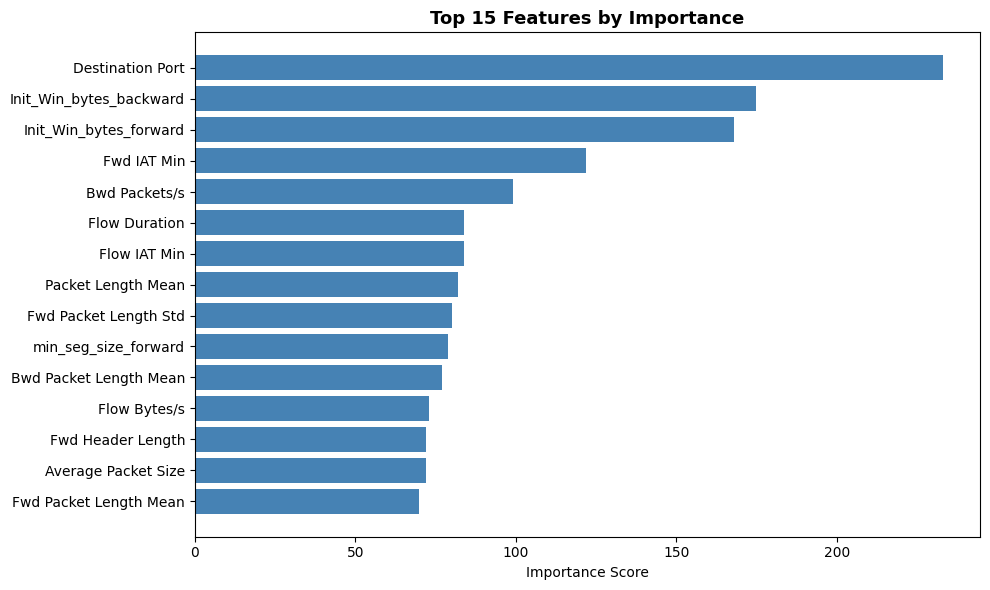


📊 Number of features needed for 80% importance: 34 / 78
   Percentage of features used: 43.6%


In [40]:
# Feature Importance Analysis — Detect Potential Data Leakage
# Get feature importances from LightGBM
importances = model.feature_importances_
feature_names = X.columns.tolist()

# Sort by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('=' * 60)
print('TOP 20 MOST IMPORTANT FEATURES (Data Leakage Detection)')
print('=' * 60)
print(importance_df.head(20).to_string(index=False))
print('\n⚠️  If a few features dominate (>80% of importance),')
print('   this could indicate data leakage or inherent dataset bias.\n')

# Visualize top 15 features
fig, ax = plt.subplots(figsize=(10, 6))
top_15 = importance_df.head(15)
ax.barh(range(len(top_15)), top_15['Importance'].values, color='steelblue')
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Features by Importance', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Calculate cumulative importance
importance_df['Cumulative'] = importance_df['Importance'].cumsum()
total_importance = importance_df['Importance'].sum()
importance_df['Cumulative_Pct'] = (importance_df['Cumulative'] / total_importance) * 100

# How many features needed for 80% importance?
n_features_80 = (importance_df['Cumulative_Pct'] <= 80).sum() + 1
print(f'\n📊 Number of features needed for 80% importance: {n_features_80} / {len(feature_names)}')
print(f'   Percentage of features used: {(n_features_80 / len(feature_names)) * 100:.1f}%')
if n_features_80 < len(feature_names) * 0.3:
    print('   ⚠️  ALERT: Very few features dominate! High risk of data leakage.')


In [41]:
# Sample for SHAP (keep manageable)
SHAP_SAMPLE = min(1000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE, random_state=42)

# Build explainer ONCE 
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)  # list of arrays, one per class

print(f'SHAP values computed for {SHAP_SAMPLE} samples.')
print(f'shap_values type: {type(shap_values)}')
if isinstance(shap_values, list):
    print(f'Number of class outputs: {len(shap_values)}')
    print(f'Shape per class: {shap_values[0].shape}')

SHAP values computed for 1000 samples.
shap_values type: <class 'numpy.ndarray'>


Showing SHAP summary for class: "BENIGN" (index 0)


<Figure size 1000x700 with 0 Axes>

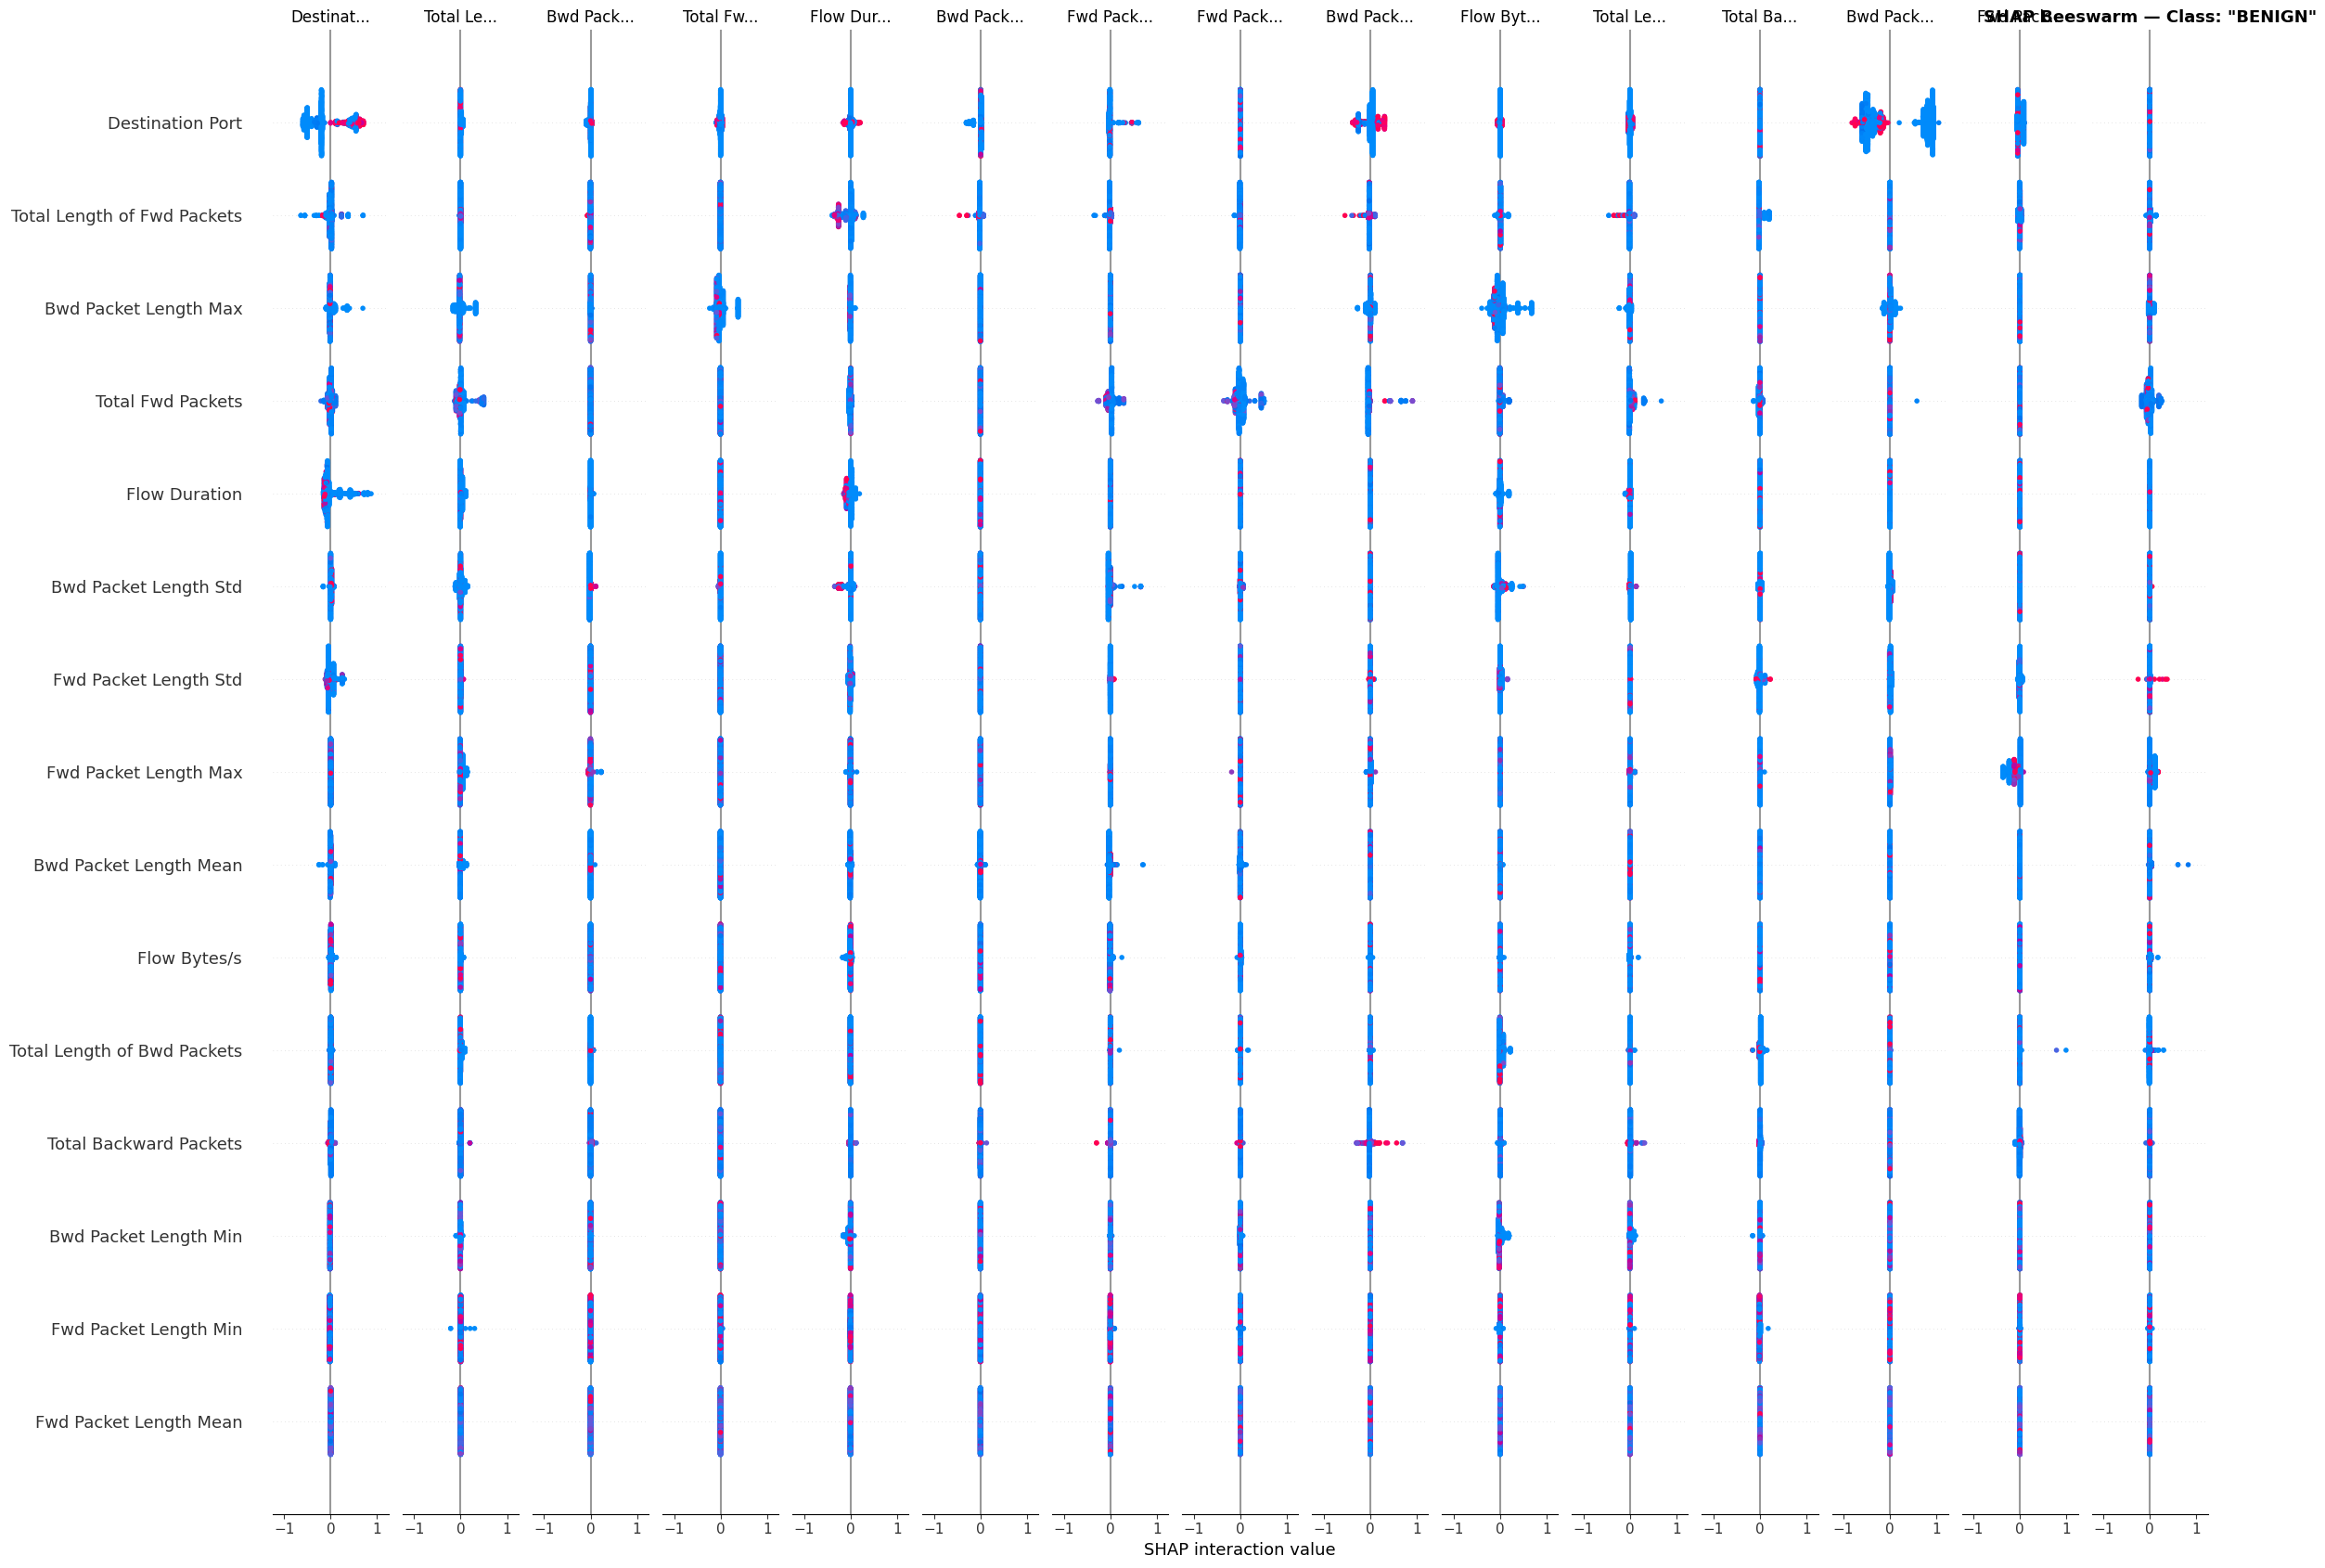

In [42]:
# Pick the class with highest representation in test set for the summary plot
top_class_idx = int(np.bincount(y_test.values).argmax())
top_class_name = class_names[top_class_idx]

shap_for_class = shap_values[top_class_idx] if isinstance(shap_values, list) else shap_values

print(f'Showing SHAP summary for class: "{top_class_name}" (index {top_class_idx})')

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_for_class,
    X_shap,
    plot_type='dot',
    max_display=20,
    show=False,
    title=f'SHAP Summary — Class: "{top_class_name}"'
)
plt.title(f'SHAP Beeswarm — Class: "{top_class_name}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
# summary table of metrics
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)',
               'F1-Score (weighted)', 'Log Loss', 'AUC-ROC (weighted OvR)'],
    'Score' : [acc, prec, rec, f1, ll, auc]
})
summary['Score'] = summary['Score'].round(5)
print(summary.to_string(index=False))

                Metric   Score
              Accuracy 0.92408
  Precision (weighted) 0.98740
     Recall (weighted) 0.92408
   F1-Score (weighted) 0.95251
              Log Loss 1.05508
AUC-ROC (weighted OvR) 0.99734


In [44]:
# QUICK AUDIT - Find highest correlations with label
print('🚨 QUICK DATA LEAKAGE CHECK 🚨\n')

# Calculate correlations
correlations = []
for col in X.columns:
    corr = X[col].corr(y)
    correlations.append({'Feature': col, 'Abs_Corr': abs(corr)})

corr_df = pd.DataFrame(correlations).sort_values('Abs_Corr', ascending=False)

# Show top 20 features with highest correlation to label
print('TOP 20 FEATURES BY CORRELATION WITH LABEL:')
print(corr_df.head(20).to_string(index=False))

# Count suspicious features
high_corr = corr_df[corr_df['Abs_Corr'] > 0.6]
print(f'\n⚠️  Features with |correlation| > 0.6: {len(high_corr)} out of {len(corr_df)}')

# Per-class performance summary
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, support = precision_recall_fscore_support(
    y_test, y_pred, average=None, zero_division=0
)

per_class = pd.DataFrame({
    'Class': class_names,
    'F1': f1,
    'Support': support
}).sort_values('F1', ascending=False)

print('\n\nPER-CLASS F1-SCORE (sorted):')
print(per_class.to_string(index=False))

# Prediction confidence
max_prob = y_pred_prob.max(axis=1)
print(f'\n\nPREDICTION CONFIDENCE:')
print(f'  Mean: {max_prob.mean():.6f}')
print(f'  % with confidence > 0.999: {(max_prob > 0.999).sum()/len(max_prob)*100:.2f}%')


🚨 QUICK DATA LEAKAGE CHECK 🚨

TOP 20 FEATURES BY CORRELATION WITH LABEL:
               Feature  Abs_Corr
        PSH Flag Count  0.305556
     Min Packet Length  0.254442
 Bwd Packet Length Min  0.227037
           Fwd IAT Std  0.206061
             Idle Mean  0.187888
              Idle Min  0.187302
              Idle Max  0.186465
           Fwd IAT Max  0.182586
 Bwd Packet Length Std  0.182386
          Flow IAT Max  0.181374
 Bwd Packet Length Max  0.172202
Bwd Packet Length Mean  0.158418
  Avg Bwd Segment Size  0.158418
Packet Length Variance  0.156053
          Flow IAT Std  0.153125
     Packet Length Std  0.152059
     Max Packet Length  0.149867
 Fwd Packet Length Min  0.115114
        URG Flag Count  0.115044
    Packet Length Mean  0.111559

⚠️  Features with |correlation| > 0.6: 0 out of 78


PER-CLASS F1-SCORE (sorted):
                     Class       F1  Support
                      DDoS 0.993629    25605
                  PortScan 0.993006    31761
                